PREPROCESSING DATA

In [28]:
%pip install python-louvain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
import community as community_louvain

# membaca dataset
df = pd.read_csv("Training.csv")
test = pd.read_csv("Testing.csv")

# mengambil semua kolom gejala
symptoms = df.columns[:-1]

In [30]:
# menghilangkan kolom tidak penting
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [31]:
df.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)

In [32]:
# mengambil daftar unik penyakit dan gejala
penyakit_list = df['prognosis'].unique().tolist()
gejala_list = [col for col in df.columns if col != 'prognosis']

print(f"Total Penyakit: {len(penyakit_list)}")
print(f"Total Gejala: {len(gejala_list)}\n")

# agregasi data agar tahu relasi unik antara penyakit dan gejala
df_grouped = df.groupby('prognosis').max().reset_index()

Total Penyakit: 41
Total Gejala: 132



C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_49252\1779178612.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_grouped = df.groupby('prognosis').max().reset_index()


PEMBENTUKAN GRAF BIPARTIT

In [33]:
# membuat graph bipartite
B = nx.Graph()

# menambahkan node gejala dan penyakit (0 untuk gejala dan 1 untuk penyakit)
B.add_nodes_from(gejala_list, bipartite=0)
B.add_nodes_from(penyakit_list, bipartite=1)

# menambahkan edge gejala-penyakit
for _, row in df_grouped.iterrows():
    penyakit = row['prognosis']
    for gejala in gejala_list:
        if row[gejala] == 1:
            B.add_edge(gejala, penyakit)

print("--- Graf Bipartit Awal ---")
print(f"Jumlah Node: {B.number_of_nodes()}")
print(f"Jumlah Edge: {B.number_of_edges()}\n")

--- Graf Bipartit Awal ---
Jumlah Node: 173
Jumlah Edge: 321



PROYEKSI GRAF

In [34]:
# memproyeksikan ke disease network dan menggunakan weighted projection agar edge memiliki bobot berdasarkan jumlah gejala yang sama
G_disease = bipartite.weighted_projected_graph(B, penyakit_list)

print("--- Hasil Proyeksi Graf (Jaringan Penyakit) ---")
print(f"Jumlah Node Penyakit: {G_disease.number_of_nodes()}")
print(f"Jumlah Edge Antar Penyakit: {G_disease.number_of_edges()}\n")

--- Hasil Proyeksi Graf (Jaringan Penyakit) ---
Jumlah Node Penyakit: 41
Jumlah Edge Antar Penyakit: 380



In [35]:
# sampel bobot edge teratas
edges_sample = sorted(G_disease.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:3]
print("Contoh Penyakit dengan Gejala Beririsan Terbanyak:")
for u, v, d in edges_sample:
    print(f" - {u} & {v} berbagi {d['weight']} gejala yang sama.")
print()

Contoh Penyakit dengan Gejala Beririsan Terbanyak:
 - Hepatitis D & Hepatitis E berbagi 9 gejala yang sama.
 - Tuberculosis & Pneumonia berbagi 9 gejala yang sama.
 - hepatitis A & Hepatitis D berbagi 8 gejala yang sama.



ANALISIS SENTRALITAS JARINGAN

In [36]:
# menghitung metrik sentralitas pada Graf Proyeksi Penyakit
degree_cent = nx.degree_centrality(G_disease)
betweenness_cent = nx.betweenness_centrality(G_disease, weight='weight')
closeness_cent = nx.closeness_centrality(G_disease)

In [37]:
# membuat DataFrame untuk menampilkan hasil sentralitas
df_centrality = pd.DataFrame({
    'Penyakit': penyakit_list,
    'Degree Centrality': [degree_cent[p] for p in penyakit_list],
    'Betweenness Centrality': [betweenness_cent[p] for p in penyakit_list],
    'Closeness Centrality': [closeness_cent[p] for p in penyakit_list]
})

print("--- Top 5 Penyakit Berdasarkan Betweenness Centrality (Bridge) ---")
print(df_centrality.sort_values(by='Betweenness Centrality', ascending=False).head(5).to_string(index=False))
print()

--- Top 5 Penyakit Berdasarkan Betweenness Centrality (Bridge) ---
     Penyakit  Degree Centrality  Betweenness Centrality  Closeness Centrality
       Dengue              0.925                0.097499              0.930233
         GERD              0.550                0.064413              0.689655
      Typhoid              0.800                0.063215              0.816327
Drug Reaction              0.275                0.061244              0.563380
     Impetigo              0.375                0.052696              0.606061



DETEKSI KOMUNITAS (ALGORITMA LOUVAIN)

In [38]:
# mendeteksi komunitas otomatis berdasarkan struktur topologi graf
partition = community_louvain.best_partition(G_disease, weight='weight')

# masukkan hasil partisi/kluster ke DataFrame
df_centrality['Komunitas'] = df_centrality['Penyakit'].map(partition)

print("--- Hasil Pengelompokkan Otomatis (Komunitas) ---")
jumlah_komunitas = len(set(partition.values()))
print(f"Ditemukan {jumlah_komunitas} komunitas penyakit.\n")

--- Hasil Pengelompokkan Otomatis (Komunitas) ---
Ditemukan 5 komunitas penyakit.



In [44]:
# menampilkan isi dari setiap komunitas
for com in sorted(set(partition.values())):
    anggota = df_centrality[df_centrality['Komunitas'] == com]['Penyakit'].tolist()
    print(f"Komunitas {com + 1} (Total: {len(anggota)} penyakit):")
    print(f" -> {', '.join(anggota[:5])} ... (dst)") # Menampilkan 5 sampel saja agar tidak kepanjangan
print()

Komunitas 1 (Total: 8 penyakit):
 -> Fungal infection, Drug Reaction, Chicken pox, Dengue, Acne ... (dst)
Komunitas 2 (Total: 8 penyakit):
 -> Allergy, GERD, AIDS, Bronchial Asthma, Tuberculosis ... (dst)
Komunitas 3 (Total: 9 penyakit):
 -> Chronic cholestasis, Peptic ulcer diseae, Jaundice, hepatitis A, Hepatitis B ... (dst)
Komunitas 4 (Total: 8 penyakit):
 -> Diabetes , Migraine, Varicose veins, Hypothyroidism, Hyperthyroidism ... (dst)
Komunitas 5 (Total: 8 penyakit):
 -> Gastroenteritis, Hypertension , Cervical spondylosis, Paralysis (brain hemorrhage), Malaria ... (dst)



VISUALISASI HASIL DETEKSI KOMUNITAS

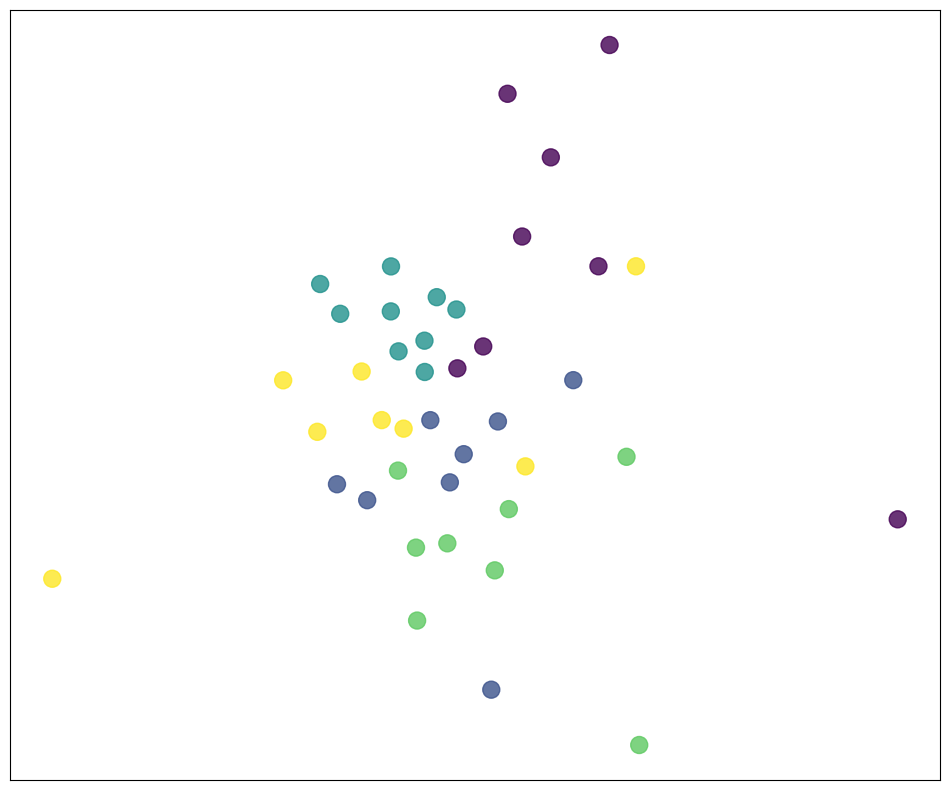

In [40]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_disease, seed=42, k=0.5) # Mengatur posisi node

# mewarnai node berdasarkan komunitasnya
cmap = plt.get_cmap('viridis', jumlah_komunitas)
colors = [partition[node] for node in G_disease.nodes()]

# menggambar node
nx.draw_networkx_nodes(G_disease, pos, node_size=150, cmap=cmap, node_color=colors, alpha=0.8)

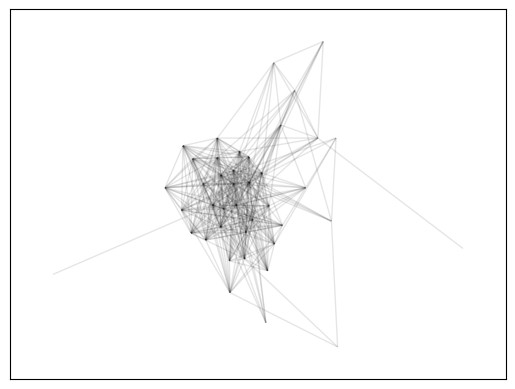

In [41]:
# menggambar edge
nx.draw_networkx_edges(G_disease, pos, alpha=0.1)

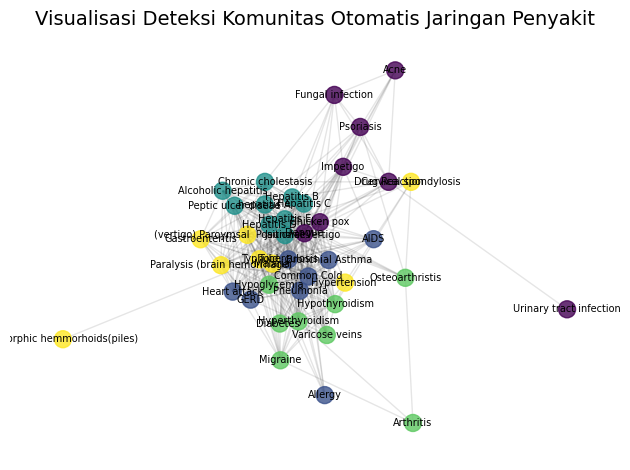

In [42]:
# menggambar node dan edge dengan label
nx.draw_networkx_nodes(G_disease, pos, node_size=150, cmap=cmap, node_color=colors, alpha=0.8)
nx.draw_networkx_edges(G_disease, pos, alpha=0.1)
nx.draw_networkx_labels(G_disease, pos, font_size=7, font_family='sans-serif')
plt.title("Visualisasi Deteksi Komunitas Otomatis Jaringan Penyakit", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

ANALISIS DEGREE

In [43]:
# menghitung degree (jumlah koneksi) langsung dari Graf Bipartit awal (B)
degree_bipartite = dict(B.degree())

# memisahkan data degree untuk penyakit dan gejala
degree_penyakit = {node: degree_bipartite[node] for node in penyakit_list}
degree_gejala = {node: degree_bipartite[node] for node in gejala_list}

# menampilkan Top 5 Gejala yang paling sering muncul di berbagai penyakit
df_degree_gejala = pd.DataFrame(list(degree_gejala.items()), columns=['Gejala', 'Degree (Jumlah Penyakit)'])
print("--- Top 5 Gejala Paling Umum (Dari Program Awal) ---")
print(df_degree_gejala.sort_values(by='Degree (Jumlah Penyakit)', ascending=False).head(5).to_string(index=False))

--- Top 5 Gejala Paling Umum (Dari Program Awal) ---
    Gejala  Degree (Jumlah Penyakit)
   fatigue                        17
  vomiting                        17
high_fever                        12
    nausea                        10
  headache                        10
